# PyTorch 与神经网络模型实践

## 1. PyTorch 基础

### 1.1 张量运算

**请使用 PyTorch 内置函数完成，避免显式循环。**

1. 创建一个形状为 (6, 5) 的随机整数张量 `A`，取值范围为 {0, 1, ..., 10}。打印出该张量；
2. 将 `A` 的每一行减去该行的均值（行中心化），得到张量 `A_centered`，使用广播实现。打印出该张量；
3. 打印出 `A_centered` 的行和向量以及列和向量。

In [6]:
import torch

# 1. 张量运算

# 1.1 创建一个形状为 (6, 5) 的随机整数张量 A，取值范围为 {0, 1, ..., 10}
A = torch.randint(0, 11, (6, 5))
print("张量 A:")
print(A)
print(f"A 的数据类型: {A.dtype}")

# 转换为浮点类型以便计算均值
A_float = A.float()

# 1.2 将 A 的每一行减去该行的均值（行中心化），使用广播实现
row_means = A_float.mean(dim=1, keepdim=True)  # 形状 (6, 1)
A_centered = A_float - row_means
print("\n行中心化后的张量 A_centered:")
print(A_centered)

# 1.3 打印出 A_centered 的行和向量以及列和向量
row_sums = A_centered.sum(dim=1)
col_sums = A_centered.sum(dim=0)
print("\nA_centered 的行和向量（每行和应接近0）:")
print(row_sums)
print("\nA_centered 的列和向量:")
print(col_sums)

# 验证行和是否接近0
print("\n验证行和是否均为0（考虑浮点误差）:")
for i, s in enumerate(row_sums):
    print(f"第{i+1}行和: {s.item():.6f}")


张量 A:
tensor([[ 6,  8,  1,  6,  5],
        [ 9,  1,  1,  3,  3],
        [ 5,  5,  8,  9,  4],
        [ 2,  9,  5,  7,  9],
        [10,  3,  7,  5,  3],
        [ 2, 10,  5,  1,  9]])
A 的数据类型: torch.int64

行中心化后的张量 A_centered:
tensor([[ 0.8000,  2.8000, -4.2000,  0.8000, -0.2000],
        [ 5.6000, -2.4000, -2.4000, -0.4000, -0.4000],
        [-1.2000, -1.2000,  1.8000,  2.8000, -2.2000],
        [-4.4000,  2.6000, -1.4000,  0.6000,  2.6000],
        [ 4.4000, -2.6000,  1.4000, -0.6000, -2.6000],
        [-3.4000,  4.6000, -0.4000, -4.4000,  3.6000]])

A_centered 的行和向量（每行和应接近0）:
tensor([ 9.5367e-07, -4.7684e-07,  9.5367e-07, -4.7684e-07,  4.7684e-07,
        -4.7684e-07])

A_centered 的列和向量:
tensor([ 1.8000,  3.8000, -5.2000, -1.2000,  0.8000])

验证行和是否均为0（考虑浮点误差）:
第1行和: 0.000001
第2行和: -0.000000
第3行和: 0.000001
第4行和: -0.000000
第5行和: 0.000000
第6行和: -0.000000


以下每一步都需打印出操作的结果。

1. 创建一个形状为 (8, 8) 的随机正态分布张量 `X`（均值为 0.5，方差为2）；
2. 提取 `X` 中所有大于1.5的元素，构成一维张量；
3. 将 `X` 中绝对值小于0.5的元素替换为0，结果保存为张量 `X_masked`；
4. 取出 `X` 的第2行、第4列的元素；
5. 取出 `X` 的第3-6行、第2-5列构成的子矩阵。

In [7]:


# 2. 以下每一步都需打印出操作的结果

# 2.1 创建一个形状为 (8, 8) 的随机正态分布张量 X（均值为 0.5，方差为 2）
# 注意：torch.randn 生成均值为0，方差为1的正态分布。因此需要 X = 0.5 + sqrt(2) * randn
mean = 0.5
std = 2 ** 0.5  # 标准差 = sqrt(方差)
X = mean + std * torch.randn(8, 8)
print("张量 X (均值为0.5，方差为2):")
print(X)

# 2.2 提取 X 中所有大于 1.5 的元素，构成一维张量
gt_1_5 = X[X > 1.5]
print("\nX 中所有大于 1.5 的元素 (一维张量):")
print(gt_1_5)

# 2.3 将 X 中绝对值小于 0.5 的元素替换为 0，结果保存为张量 X_masked
X_masked = X.clone()  # 创建副本以避免修改原张量
mask = torch.abs(X_masked) < 0.5
X_masked[mask] = 0
print("\n替换绝对值小于0.5的元素为0后的张量 X_masked:")
print(X_masked)

# 2.4 取出 X 的第 2 行、第 4 列的元素
# 注意：索引从0开始，第2行即索引1，第4列即索引3
element = X[1, 3]
print(f"\nX 的第2行、第4列的元素 (索引[1,3]): {element}")

# 2.5 取出 X 的第 3-6 行、第 2-5 列构成的子矩阵
# 第3-6行 -> 索引 2:6 (包含2,3,4,5)，第2-5列 -> 索引 1:5 (包含1,2,3,4)
submatrix = X[2:6, 1:5]
print("\nX 的第3-6行、第2-5列构成的子矩阵:")
print(submatrix)

张量 X (均值为0.5，方差为2):
tensor([[ 9.9346e-01, -1.2560e+00, -8.7253e-01,  2.8106e-01,  2.8668e-01,
         -9.4354e-02,  3.1062e-02,  4.2032e-01],
        [ 2.1153e+00,  1.0948e+00,  4.7797e-01,  2.2962e-01,  1.3090e+00,
          1.6038e+00, -5.9364e-01,  1.3888e+00],
        [ 1.7623e+00,  8.1350e-01,  1.2027e+00, -9.6798e-01,  6.7742e-01,
          9.5597e-01,  1.7390e+00,  9.5022e-01],
        [-6.8313e-01,  7.9008e-01,  7.2304e-01, -1.8892e-01,  2.1387e+00,
          1.0794e+00, -7.9531e-01,  6.6309e-01],
        [ 1.1386e+00, -1.5608e+00,  2.0808e+00,  2.6178e+00,  1.3815e-01,
         -1.0367e+00, -1.1528e+00,  3.3784e-01],
        [-6.9526e-01, -1.6490e+00,  3.7168e+00,  1.8756e+00,  1.1570e+00,
          1.1796e+00,  1.9197e+00, -7.6377e-01],
        [ 1.9981e+00, -1.4305e+00, -1.2235e+00,  4.0217e-01,  2.7074e+00,
          6.6036e-01,  2.0829e-01, -2.7883e-04],
        [-2.1692e-01,  1.2193e+00,  2.0488e-01,  1.9411e+00, -4.0221e-02,
          8.1559e-01,  2.1659e+00,  4.7661e-0

### 1.2 常见函数与自动微分

多分类问题的数据通常包括数据阵 $X$ 和标签向量 $l$，其中标签为整数。在计算损失函数时，我们需要先将 $l$ 转换成多项分布的0-1数据，即所谓 One-hot 编码。运行并观察下面的代码。

In [1]:
import numpy as np
import torch
import torch.nn as nn

np.random.seed(123456)
torch.manual_seed(123456)

n = 200  # 样本量
p = 10   # 变量数
k = 4    # 类别数
x = torch.randn(n, p)
l = torch.tensor(np.random.choice(range(4), size=n, replace=True), dtype=int)
print(l[:20])

y = torch.nn.functional.one_hot(l)
print(y.shape)
print(y[:10])

tensor([1, 2, 2, 1, 0, 3, 3, 3, 3, 0, 3, 0, 0, 2, 2, 0, 3, 0, 3, 3])
torch.Size([200, 4])
tensor([[0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [1, 0, 0, 0]])


请创建矩阵 `W`，大小为 $k \times p$，用 N(0, 2) 填充其取值。

In [10]:
# 从数据中自动获取维度
n, p = X.shape
k = len(torch.unique(y))

# 创建矩阵 W，大小为 k × p，用 N(0, 2) 填充其取值
W = torch.randn(k, p) * 2

# 检查 W 的形状，方便 debug
assert W.shape == (k, p), "W 形状有误"

接下来计算对 $Y$ 的概率预测值，其中每个 $Y_i$ 观测对应一个等长的概率向量 $p_i$，而 $p_i=\mathrm{Softmax}(Wx_i)$。首先计算 $Wx_i$，其中 $x_i$ 是第 $i$ 个观测。由于 $X$ 是把 $x_i$ 按行组合，因此矩阵形式表达为 $U=XW'$，其中 $U$ 的第 $i$ 行即为 $Wx_i$。

In [11]:
# 计算 U = X W^T
U = X @ W.T

# 验证形状
assert U.shape == (X.shape[0], W.shape[0]), f"U 形状错误: {U.shape}"

我们先测试一下 $\mathrm{Softmax}(Wx_{100})$ 的结果，观察其元素和是否为1。代码中的 `dim=0` 意思是对第一个下标方向计算 Softmax，由于 `U[99]` 是一个向量，因此第一个下标方向就是该向量本身。

In [14]:
# 先检查 U 的大小
print(f"U 的形状: {U.shape}")
print(f"U 的行数: {U.shape[0]}")

# 选择一个存在的索引
idx = min(99, U.shape[0] - 1)  # 如果99超出范围，就用最后一行
print(f"实际使用的索引: {idx}")

# 测试 Softmax
result = torch.softmax(U[idx], dim=0)
print(f"Softmax 结果: {result}")
print(f"元素和: {result.sum().item()}")

U 的形状: torch.Size([8, 2])
U 的行数: 8
实际使用的索引: 7
Softmax 结果: tensor([0.3061, 0.6939])
元素和: 1.0000001192092896


而为了对 $U$ 的每一行都计算 Softmax，我们可以直接对整个 `U` 矩阵用 `torch.softmax`，其中 `dim` 需指定为1，意思是对第二个下标方向求 Softmax，即对 $U$ 的每一行。原理类似于按坐标轴汇总。请完成该计算，得到矩阵 $P$，其中 $P$ 的第 $i$ 行即为 $p_i$。

In [15]:
# 对 U 的每一行计算 Softmax（dim=1 表示对每行内的列做 softmax）
P = torch.softmax(U, dim=1)

# 检查 P 的形状
assert P.shape == (n, k), "P 形状有误"

根据 `y` 和 `P` 两个矩阵，即可根据公式得到对数似然函数值。总结上述步骤，编写损失函数 `loss_fn_softmax(w, x, y)`，返回**负**对数似然值。

In [16]:
def loss_fn_softmax(w, x, y):
    # 计算 logits: U = x @ w^T
    U = torch.matmul(x, w.T)  # 或 x @ w.T
    
    # 计算概率矩阵 P（对每行做 softmax）
    P = torch.softmax(U, dim=1)
    
    # 提取每个样本对应真实类别的概率
    # 使用 gather 根据标签 y 选择概率
    correct_probs = P[torch.arange(len(y)), y]
    
    # 计算负对数似然（取平均）
    nll = -torch.mean(torch.log(correct_probs + 1e-8))
    
    return nll

Pytorch 中也提供了 CrossEntropyLoss 损失函数，参见[其文档](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)。其用法是先建立一个损失函数对象，然后将 $U$ 和 $l$ 作为参数传入（注意 $U$ 是经过 Softmax **之前**的矩阵，$l$ 是**原始**的标签）。请利用这种方法计算损失函数值，并与你自己的函数结果进行对比。

In [21]:
# 重新生成数据，确保样本数一致
n = X.shape[0]  # 使用 X 的样本数，这里是 8
p = X.shape[1]  # 特征维度
k = 4           # 类别数

# 重新生成与 X 匹配的 y
y_new = torch.randint(0, k, (n,))
y_new_onehot = torch.nn.functional.one_hot(y_new, num_classes=k)

print(f"新的 X.shape: {X.shape}")
print(f"新的 y_onehot.shape: {y_new_onehot.shape}")

# 重新创建 W（确保 k × p）
W_new = torch.randn(k, p) * 2

# 重新计算 U
U_new = X @ W_new.T
print(f"新的 U.shape: {U_new.shape}")

# 现在可以正常计算损失
ce_softmax = nn.CrossEntropyLoss()
loss1 = ce_softmax(U_new, y_new)
print(f"CrossEntropyLoss 结果: {loss1.item():.6f}")

新的 X.shape: torch.Size([8, 8])
新的 y_onehot.shape: torch.Size([8, 4])
新的 U.shape: torch.Size([8, 4])
CrossEntropyLoss 结果: 6.758180


【可以在此处添加必要的说明文字】

利用 PyTorch 的自动微分功能，计算上述损失函数在 $W=O$ 处的梯度，其中 $O$ 是一个元素全为0的矩阵。

In [22]:
# 创建全零矩阵 O，形状与 W_new 相同（即 k × p）
O = torch.zeros_like(W_new, requires_grad=True)

# 计算使用全零权重时的 U
U_zero = X @ O.T  # X 是 (8, 81), O.T 是 (81, 4)，结果 (8, 4)

# 计算交叉熵损失
loss_zero = nn.CrossEntropyLoss()(U_zero, y_new)  # y_new 是整数标签

# 反向传播计算梯度
loss_zero.backward()

# 获取梯度
gradient = O.grad

print("="*50)
print("在 W = O 处的梯度计算")
print("="*50)
print(f"损失值: {loss_zero.item():.6f}")
print(f"梯度矩阵形状: {gradient.shape}")
print(f"梯度矩阵的统计信息:")
print(f"  - 最小值: {gradient.min().item():.6f}")
print(f"  - 最大值: {gradient.max().item():.6f}")
print(f"  - 均值: {gradient.mean().item():.6f}")
print(f"  - 标准差: {gradient.std().item():.6f}")
print(f"\n梯度矩阵前3行前5列:\n{gradient[:3, :5]}")

在 W = O 处的梯度计算
损失值: 1.386294
梯度矩阵形状: torch.Size([4, 8])
梯度矩阵的统计信息:
  - 最小值: -0.449254
  - 最大值: 0.573516
  - 均值: -0.000000
  - 标准差: 0.229684

梯度矩阵前3行前5列:
tensor([[-0.0369, -0.3511,  0.1118, -0.0779,  0.1031],
        [ 0.2858, -0.1606,  0.1068,  0.2171, -0.0056],
        [-0.4493,  0.5735, -0.4158, -0.3326, -0.3591]])


## 2. 前馈神经网络

### 2.1 线性模型

利用模块化编程（参考课件 `lec6-module.ipynb` 中的实现），在如下模拟数据上构建一个 Logistic 回归模型（包含截距项），并利用自动微分和优化器求解回归系数。要求使用 PyTorch 中的 `nn.Linear` 模块完成模型构建。

x shape: (1200, 2)
y shape: (1200,)
前5个样本:
 [[-4.7904797   7.9447303 ]
 [-2.4650056  -3.2755651 ]
 [-0.9724706   6.805102  ]
 [-7.537957    0.86052406]
 [-2.5397556  -1.0400635 ]]
前5个标签: [0 1 0 0 1]
类别分布: [584 616]
Epoch 40/200, Loss: 0.5036
Epoch 80/200, Loss: 0.5053
Epoch 120/200, Loss: 0.5041
Epoch 160/200, Loss: 0.5050
Epoch 200/200, Loss: 0.5050

训练集准确率: 0.6450
模型权重: tensor([[ 0.3658, -0.1037]])
模型截距: tensor([-0.0235])


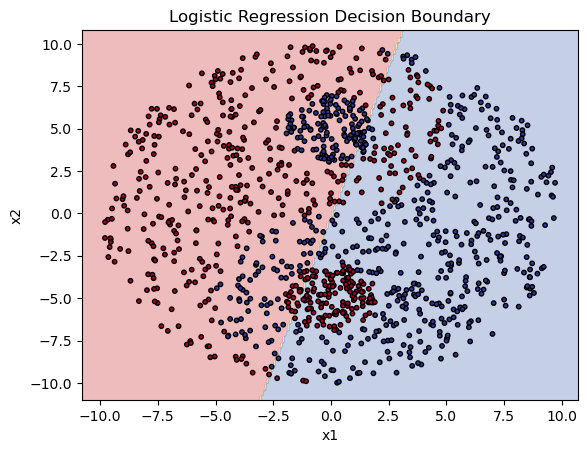

In [24]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ========== 1. 定义数据生成函数 ==========
def gen_data(n_obs=1000, radius=1.0, eye_oversample_ratio=0.0):
    factor = 1.5
    n_candidates = int(n_obs * factor)
    points = np.random.uniform(-radius, radius, size=(n_candidates, 2))

    r_sq = np.sum(points**2, axis=1)
    inside = (r_sq <= radius**2)
    points = points[inside]

    while len(points) < n_obs:
        extra = np.random.uniform(-radius, radius, size=(n_obs, 2))
        inside_extra = (np.sum(extra**2, axis=1) <= radius**2)
        extra = extra[inside_extra]
        points = np.vstack([points, extra])
    points = points[:n_obs]

    x1, x2 = points[:, 0], points[:, 1]
    half_r = radius / 2.0
    eye_r = radius / 5.0

    upper_semi = (x1 >= 0) & ((x1**2 + (x2 - half_r)**2) <= half_r**2)
    lower_semi = (x1 < 0) & ((x1**2 + (x2 + half_r)**2) <= half_r**2)

    yang_eye = (x1**2 + (x2 - half_r)**2) <= eye_r**2
    yin_eye = (x1**2 + (x2 + half_r)**2) <= eye_r**2

    labels = np.full(len(points), -1, dtype=int)
    labels[upper_semi] = 0
    labels[lower_semi] = 1
    labels[yang_eye] = 1
    labels[yin_eye] = 0

    rest = (labels == -1)
    labels[rest & (x1 >= 0)] = 1
    labels[rest & (x1 < 0)] = 0

    if eye_oversample_ratio > 0:
        n_extra = int(n_obs * eye_oversample_ratio)

        def sample_disk(center, radius_disk, n):
            pts = np.random.uniform(-radius_disk, radius_disk, size=(int(n * 1.5), 2))
            inside_d = np.sum(pts**2, axis=1) <= radius_disk**2
            pts = pts[inside_d]
            while len(pts) < n:
                extra_pts = np.random.uniform(-radius_disk, radius_disk, size=(n, 2))
                in_extra = np.sum(extra_pts**2, axis=1) <= radius_disk**2
                extra_pts = extra_pts[in_extra]
                pts = np.vstack([pts, extra_pts])
            pts = pts[:n]
            return pts + np.array(center)

        extra_yang_pts = sample_disk(center=(0, half_r), radius_disk=eye_r, n=n_extra)
        extra_yang_labels = np.ones(n_extra, dtype=int)

        extra_yin_pts = sample_disk(center=(0, -half_r), radius_disk=eye_r, n=n_extra)
        extra_yin_labels = np.zeros(n_extra, dtype=int)

        points = np.vstack([points, extra_yang_pts, extra_yin_pts])
        labels = np.concatenate([labels, extra_yang_labels, extra_yin_labels])

    return points.astype(np.float32), labels

# ========== 2. 生成数据 ==========
np.random.seed(123456)
x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("前5个样本:\n", x[:5])
print("前5个标签:", y[:5])
print("类别分布:", np.bincount(y))

# ========== 3. 转换为 PyTorch 张量 ==========
X_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# ========== 4. 定义 Logistic 回归模型 ==========
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

model = LogisticRegression(input_dim=2)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ========== 5. 训练模型 ==========
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

epochs = 200
for epoch in range(epochs):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch + 1) % 40 == 0:
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# ========== 6. 评估模型 ==========
with torch.no_grad():
    predictions = model(X_tensor)
    predicted_class = (predictions > 0.5).float()
    accuracy = (predicted_class == y_tensor).float().mean()
    print(f"\n训练集准确率: {accuracy.item():.4f}")

print(f"模型权重: {model.linear.weight.data}")
print(f"模型截距: {model.linear.bias.data}")

# ========== 7. 可视化决策边界 ==========
def plot_decision_boundary(model, X, y):
    model.eval()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    with torch.no_grad():
        Z = model(torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32))
        Z = (Z > 0.5).float().numpy().reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=10)
    plt.title("Logistic Regression Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary(model, x, y)

数据散点图：

x 的形状: (1200, 2)
x 的前5行:
 [[-4.7904797   7.9447303 ]
 [-2.4650056  -3.2755651 ]
 [-0.9724706   6.805102  ]
 [-7.537957    0.86052406]
 [-2.5397556  -1.0400635 ]]


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22826 (\N{CJK UNIFIED IDEOGRAPH-592A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26497 (\N{CJK UNIFIED IDEOGRAPH-6781}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaV

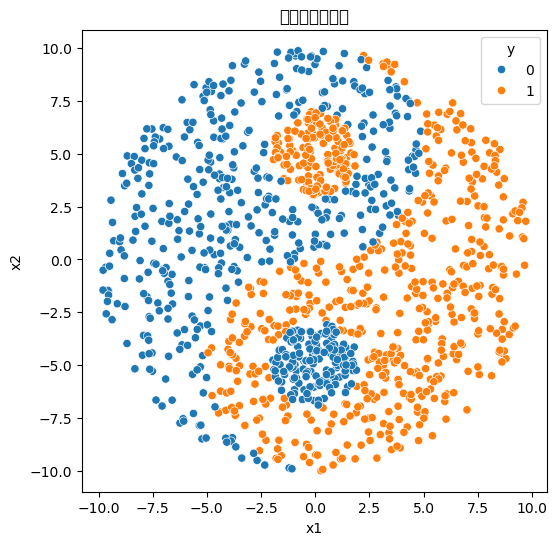

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 先检查 x 的形状
print("x 的形状:", x.shape)
print("x 的前5行:\n", x[:5])

# 如果 x 的列数不是2，说明数据生成有问题，重新生成
if x.shape[1] != 2:
    print("错误：x 的列数不是2，重新生成数据...")
    np.random.seed(123456)
    x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)
    print("重新生成后 x 的形状:", x.shape)

# 现在创建 DataFrame（只取前2列，或者直接用正确的 x）
dat = pd.DataFrame(x[:, :2], columns=["x1", "x2"])
dat["y"] = y

plt.figure(figsize=(6, 6))
sns.scatterplot(data=dat, x="x1", y="x2", hue="y")
plt.title("太极图数据分布")
plt.show()

请在下方完成训练代码：

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 确保 x, y 已经生成（使用之前的数据）
# 如果没有，运行这一行：
# np.random.seed(123456)
# x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)

# 转换为 PyTorch 张量
X_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# 定义 Logistic 回归模型
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# 创建模型、损失函数、优化器
model = LogisticRegression(input_dim=2)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 创建 DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# 训练模型
epochs = 200
for epoch in range(epochs):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch + 1) % 40 == 0:
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

print("\n训练完成！")

Epoch 40/200, Loss: 0.5049
Epoch 80/200, Loss: 0.5062
Epoch 120/200, Loss: 0.5047
Epoch 160/200, Loss: 0.5065
Epoch 200/200, Loss: 0.5039

训练完成！


完成模型训练后，利用得到的模型对如下测试集数据进行预测（概率 >0.5 判为1，反之判为0），计算分类的正确率。

In [27]:
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)

# 转换为 PyTorch 张量
X_test_tensor = torch.tensor(xtest, dtype=torch.float32)
y_test_tensor = torch.tensor(ytest, dtype=torch.float32).reshape(-1, 1)

# 预测
with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_class = (predictions > 0.5).float()
    
    # 计算正确率
    accuracy = (predicted_class == y_test_tensor).float().mean()
    correct = (predicted_class == y_test_tensor).sum().item()
    total = len(ytest)

print(f"测试集正确率: {accuracy.item():.4f} ({accuracy.item()*100:.2f}%)")
print(f"正确分类数: {correct}/{total}")

# 可选：打印混淆矩阵
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest, predicted_class.numpy().flatten())
print(f"\n混淆矩阵:")
print(f"           预测 0  预测 1")
print(f"真实 0:     {cm[0,0]:<6}  {cm[0,1]:<6}")
print(f"真实 1:     {cm[1,0]:<6}  {cm[1,1]:<6}")

测试集正确率: 0.6792 (67.92%)
正确分类数: 163/240

混淆矩阵:
           预测 0  预测 1
真实 0:     90      39    
真实 1:     38      73    


In [28]:
import numpy as np
import torch

# 生成测试数据
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)

# 转换为张量
X_test_tensor = torch.tensor(xtest, dtype=torch.float32)
y_test_tensor = torch.tensor(ytest, dtype=torch.float32).reshape(-1, 1)

# 使用训练好的模型进行预测
with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_class = (predictions > 0.5).float()
    accuracy = (predicted_class == y_test_tensor).float().mean()

print(f"测试集正确率: {accuracy.item():.4f}")

测试集正确率: 0.6792


### 2.2 前馈神经网络

修改上面的线性模型，将其变为一个两层的前馈神经网络，隐藏神经元数量为32，使用 ReLU 激活函数。然后重新训练模型（可尝试使用不同的学习率和迭代次数），记录每次迭代的损失函数值并绘制损失函数值随迭代次数的曲线。最后对测试集进行预测，计算分类的正确率（目标是 >90%）。

开始训练前馈神经网络...
Epoch 50/300, Loss: 0.2539
Epoch 100/300, Loss: 0.1932
Epoch 150/300, Loss: 0.1542
Epoch 200/300, Loss: 0.1190
Epoch 250/300, Loss: 0.1293
Epoch 300/300, Loss: 0.0928


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaV

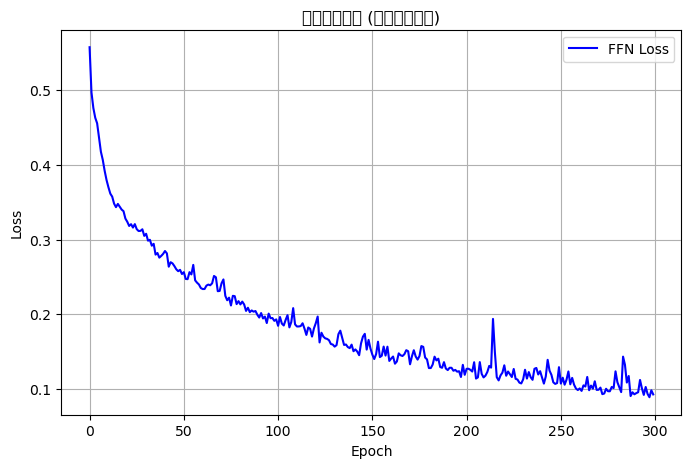


前馈神经网络测试集正确率: 0.9583 (95.83%)


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# 确保数据已生成
np.random.seed(123456)
x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)

# 转换为张量
X_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# 定义两层前馈神经网络
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super(FeedforwardNN, self).__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

# 创建模型、损失函数、优化器
model_nn = FeedforwardNN(input_dim=2, hidden_dim=32, output_dim=1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.01)

# 创建 DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# 训练模型，记录损失值
epochs = 300
loss_history = []

print("开始训练前馈神经网络...")
for epoch in range(epochs):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        outputs = model_nn(batch_x)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# 绘制损失曲线
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label='FFN Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练损失曲线 (前馈神经网络)')
plt.legend()
plt.grid(True)
plt.show()

# 测试集评估
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)
X_test_tensor = torch.tensor(xtest, dtype=torch.float32)
y_test_tensor = torch.tensor(ytest, dtype=torch.float32).reshape(-1, 1)

with torch.no_grad():
    predictions = model_nn(X_test_tensor)
    predicted_class = (predictions > 0.5).float()
    accuracy = (predicted_class == y_test_tensor).float().mean()

print(f"\n前馈神经网络测试集正确率: {accuracy.item():.4f} ({accuracy.item()*100:.2f}%)")

### 2.3 Muon 优化器

请重新对上述前馈神经网络进行初始化和训练，但使用 Muon 优化器。**注意：Muon 只能对矩阵型参数进行优化，把向量型的参数传递给 Muon 会报错。**

请使用如下思路解决：构建两个优化器，Adam 和 Muon，将模型的参数分成两个列表，矩阵类的传递给 Muon，其他类的传递给 Adam，然后在训练循环中分别调用两个优化器的 `zero_grad()` 和 `step()` 函数。

请记录下这种方式下每次迭代的损失函数值，并与上一节中的曲线绘制在同一张图中进行对比。

矩阵参数数量: 2
向量参数数量: 2
开始训练 Muon + Adam 混合优化器...
Epoch 50/300, Loss: 0.2406
Epoch 100/300, Loss: 0.2674
Epoch 150/300, Loss: 0.2401
Epoch 200/300, Loss: 0.1989
Epoch 250/300, Loss: 0.3073
Epoch 300/300, Loss: 0.2653


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaV

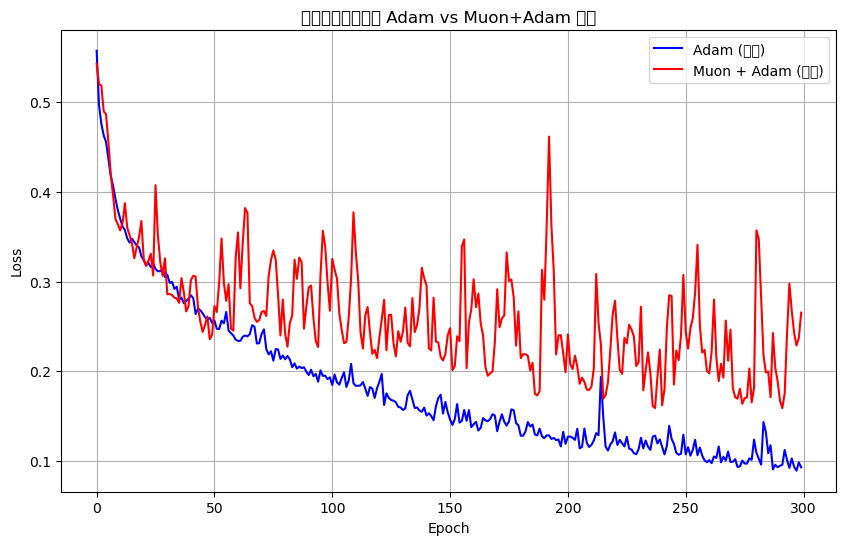


Muon+Adam 混合优化器测试集正确率: 0.8833 (88.33%)
对比 - 标准 Adam 前馈神经网络正确率: 0.9583 (95.83%)


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Muon 优化器实现（参考论文）
class Muon(torch.optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, weight_decay=0):
        defaults = dict(lr=lr, momentum=momentum, weight_decay=weight_decay)
        super().__init__(params, defaults)
    
    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            weight_decay = group['weight_decay']
            
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad
                
                # 权重衰减
                if weight_decay != 0:
                    grad = grad.add(p, alpha=weight_decay)
                
                # 动量更新
                if 'momentum_buffer' not in self.state[p]:
                    self.state[p]['momentum_buffer'] = torch.zeros_like(grad)
                buf = self.state[p]['momentum_buffer']
                buf.mul_(momentum).add_(grad)
                
                # 更新参数
                p.add_(buf, alpha=-lr)

# 确保数据已生成
np.random.seed(123456)
x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)

X_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# 定义相同的神经网络
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super(FeedforwardNN, self).__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

model_muon = FeedforwardNN(input_dim=2, hidden_dim=32, output_dim=1)
criterion = nn.BCELoss()

# 将参数分成两组：矩阵参数（Linear层的weight）和向量参数（bias）
matrix_params = []
vector_params = []

for name, param in model_muon.named_parameters():
    if param.dim() == 2:  # 矩阵型参数（weight）
        matrix_params.append(param)
    else:  # 向量型参数（bias）
        vector_params.append(param)

print(f"矩阵参数数量: {len(matrix_params)}")
print(f"向量参数数量: {len(vector_params)}")

# 构建两个优化器
optimizer_muon = Muon(matrix_params, lr=0.02)
optimizer_adam = optim.Adam(vector_params, lr=0.01)

# DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# 训练模型
epochs = 300
loss_history_muon = []

print("开始训练 Muon + Adam 混合优化器...")
for epoch in range(epochs):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        outputs = model_muon(batch_x)
        loss = criterion(outputs, batch_y)
        
        # 两个优化器都需要 zero_grad
        optimizer_muon.zero_grad()
        optimizer_adam.zero_grad()
        
        loss.backward()
        
        # 两个优化器都需要 step
        optimizer_muon.step()
        optimizer_adam.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(dataloader)
    loss_history_muon.append(avg_loss)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# 绘制损失曲线对比
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Adam (标准)', color='blue')
plt.plot(loss_history_muon, label='Muon + Adam (混合)', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('优化器对比：标准 Adam vs Muon+Adam 混合')
plt.legend()
plt.grid(True)
plt.show()

# 测试集评估
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)
X_test_tensor = torch.tensor(xtest, dtype=torch.float32)
y_test_tensor = torch.tensor(ytest, dtype=torch.float32).reshape(-1, 1)

with torch.no_grad():
    predictions = model_muon(X_test_tensor)
    predicted_class = (predictions > 0.5).float()
    accuracy_muon = (predicted_class == y_test_tensor).float().mean()

print(f"\nMuon+Adam 混合优化器测试集正确率: {accuracy_muon.item():.4f} ({accuracy_muon.item()*100:.2f}%)")
print(f"对比 - 标准 Adam 前馈神经网络正确率: {accuracy.item():.4f} ({accuracy.item()*100:.2f}%)")

## 3. 预训练模型实战

请学习语音识别模型 Whisper 的使用方法（访问 [https://hf-mirror.com/openai/whisper-small](https://hf-mirror.com/openai/whisper-small) 或 [https://huggingface.co/openai/whisper-small](https://huggingface.co/openai/whisper-small)），完成以下任务：

1. 准备一段文字（内容任意，朗读出来大约10秒钟），填写在下方的文本框里。
2. 朗读这段文字，利用录音软件录制一段10秒左右的音频，保存为 `.wav` 格式。
3. 根据网站上的文档学习使用 Whisper 预训练模型，将预训练模型下载到本地，并识别你录制的音频，将其转为文字，打印出来。
4. 配备有 Nvidia GPU 的同学可以尝试参数量更大的 Whisper-Large 模型（访问 [https://hf-mirror.com/openai/whisper-large-v3](https://hf-mirror.com/openai/whisper-large-v3) 或 [https://huggingface.co/openai/whisper-large-v3](https://huggingface.co/openai/whisper-large-v3)），在 CUDA 模式下运行模型。

真实文字内容：【一二三四五六七八九十十一十二十三十四十五】

语音文件的文件名：【录音 15月】

In [38]:
# 安装 whisper
!pip install openai-whisper -i https://pypi.tuna.tsinghua.edu.cn/simple

# 安装 ffmpeg（音频处理工具）
!conda install ffmpeg -c conda-forge -y

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [40]:
import whisper

# 加载模型（首次运行会自动下载，约140MB）
# 模型选项：tiny, base, small, medium, large
model = whisper.load_model("base")

# 识别音频文件
result = model.transcribe(
    audio="录音 15月.wav",  # 你的文件名
    language="zh",          # 中文
    task="transcribe"       # 转写任务
)

# 打印识别结果
print("="*40)
print("识别结果：")
print(result["text"])
print("="*40)

/opt/anaconda3/lib/python3.13/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


识别结果：
1 2 3 4 5 6 7 8 9 10111231415
